# Vaja 5 – Multipla regresija in interpretacija modelov

**Cilj:** Razumeti, kako regresijski modeli povezujejo več vhodnih spremenljivk z izhodno spremenljivko ter interpretirati rezultate.

**Proces:** Analiza 3D tiskanja medicinskih implantatov

**Faze:** Analyze in Improve (Lean Six Sigma)

## 0️⃣ Uvoz knjižnic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import statsmodels.api as sm
from statsmodels.formula.api import ols, logit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Knjižnice uspešno naložene")

✅ Knjižnice uspešno naložene


## 1️⃣ Priprava podatkov

### 1.1 Nalaganje podatkov

In [2]:
df = pd.read_csv('expanded_data.csv')

print(f"Dimenzije podatkov: {df.shape}")
print(f"\nPrvih 5 vrstic:")
df.head()

Dimenzije podatkov: (110, 9)

Prvih 5 vrstic:


,Iteracija,Korak,Vloga (kdo),Trajanje (h),Cakanje (h),Tip aktivnosti (VA/NVA),Napake (st),Trajanje_kategorija,Cakanje_intenziteta
0,1,Priprava 3D modela implantata,Raziskovalec,0.83,0.0,VA,0,Srednje,Brez
1,1,Pošiljanje modela v pregled,Raziskovalec,0.12,0.6,NVA,0,Kratko,Zmerno
2,1,Čakanje na odobritev,Vodja laboratorija,2.09,2.2,NVA,1,Dolgo,Dolgo
3,1,Priprava tiskalnika in materiala,Raziskovalec,0.38,0.0,VA,0,Kratko,Brez
4,1,Čakanje na prost tiskalnik,Raziskovalec,1.52,0.0,NVA,0,Dolgo,Brez


### 1.2 Opis spremenljivk

**Obstoječe spremenljivke:**

| Spremenljivka | Tip | Opis |
|---------------|-----|------|
| `Iteracija` | Numerična | Številka iteracije procesa (1-10) |
| `Korak` | Kategorična | Ime koraka v procesu 3D tiskanja |
| `Vloga (kdo)` | Kategorična | Oseba/naprava, ki izvaja korak |
| `Trajanje (h)` | Numerična | **Čas trajanja koraka v urah** |
| `Cakanje (h)` | Numerična | Čas čakanja pred korakom v urah |
| `Tip aktivnosti (VA/NVA)` | Kategorična | VA = Value Added, NVA = Non-Value Added, NNVA = Necessary Non-Value Added |
| `Napake (st)` | Numerična | Število napak v tem koraku |
| `Trajanje_kategorija` | Ordinalna | Kategorija trajanja (Kratko, Srednje, Dolgo) |
| `Cakanje_intenziteta` | Ordinalna | Intenziteta čakanja (Brez, Zmerno, Dolgo) |

### 1.3 Kreiranje novih spremenljivk

In [56]:

df_model = df.copy()

# 1. Binarna spremenljivka za napake (Ali je prišlo do napake?)
df_model['Ima_napako'] = (df_model['Napake (st)'] > 0).astype(int)

# 2. Skupni čas (Trajanje + Čakanje)
df_model['Skupni_cas'] = df_model['Trajanje (h)'] + df_model['Cakanje (h)']

# 3. Razmerje čakanja glede na trajanje
df_model['Razmerje_cakanje_trajanje'] = df_model['Cakanje (h)'] / (df_model['Trajanje (h)'] + 0.01)

# 4. Tip aktivnosti: ena binarna spremenljivka namesto dveh
# VA = 1, NVA = 0
df_model['Tip aktivnosti (VA/NVA)'] = (df_model['Tip aktivnosti (VA/NVA)'] == 'VA').astype(int)
# Če želiš bolj "čisto", jo lahko tudi preimenuješ:
# df_model.rename(columns={'Tip aktivnosti (VA/NVA)': 'Tip_aktivnosti_VA'}, inplace=True)

# 5. Kodiranje kategoričnih spremenljivk - PREPIŠEMO obstoječe stolpce
le_korak = LabelEncoder()
df_model['Korak'] = le_korak.fit_transform(df_model['Korak'])

le_vloga = LabelEncoder()
df_model['Vloga (kdo)'] = le_vloga.fit_transform(df_model['Vloga (kdo)'])

# 6. Ordinalne spremenljivke - numerično kodiranje NA MESTU
trajanje_map = {'Kratko': 0, 'Srednje': 1, 'Dolgo': 2}
cakanje_map = {'Brez': 0, 'Zmerno': 1, 'Dolgo': 2}

df_model['Trajanje_kategorija'] = df_model['Trajanje_kategorija'].map(trajanje_map)
df_model['Cakanje_intenziteta'] = df_model['Cakanje_intenziteta'].map(cakanje_map)

# 7. (Opcijsko) standardizacija numeričnih spremenljivk - PREPIŠE originalne
# Če tega nočeš, ta blok enostavno izbriši / zakomentiraj.
scaler = StandardScaler()
df_model[['Trajanje (h)', 'Cakanje (h)']] = scaler.fit_transform(
    df_model[['Trajanje (h)', 'Cakanje (h)']]
)

print("✅ String/kategoricne spremenljivke so zakodirane, odvečnih novih stolpcev ni.")

print(f"\nŠtevilo spremenljivk: {df_model.shape[1]}")
print("\nPrimer vrstic:")
print(df_model.head(10))

✅ String/kategoricne spremenljivke so zakodirane, odvečnih novih stolpcev ni.

Število spremenljivk: 12

Primer vrstic:
   Iteracija  Korak  Vloga (kdo)  Trajanje (h)  Cakanje (h)  \
0          1      7            2      0.105850    -1.203707   
1          1      6            2     -0.749048    -0.243070   
2          1      9            4      1.622991     2.318627   
3          1      8            2     -0.435987    -1.203707   
4          1     10            2      0.936665    -1.203707   
5          1      0            3      1.659113    -1.203707   
6          1      1            0      2.718704    -1.203707   
7          1      3            2     -0.640680    -0.243070   
8          1      2            1     -0.592517    -1.203707   
9          1      5            2      0.515237     0.877672   

   Tip aktivnosti (VA/NVA)  Napake (st)  Trajanje_kategorija  \
0                        1            0                    1   
1                        0            0                   

## 2️⃣ Gradnja regresijskih modelov

Zgradili bomo **4 različne regresijske modele** z **enakimi napovednimi spremenljivkami**:
- `Vloga (kdo)` - kdo izvaja korak
- `Korak` - kateri korak v procesu
- `Tip aktivnosti (VA/NVA)` - ali je aktivnost dodana vrednost
- `Napake (st)` - število napak

Modeli:
1. **Model 1:** Linearna regresija - Napovedovanje trajanja koraka
2. **Model 2:** Linearna regresija - Napovedovanje časa čakanja
3. **Model 3:** Logistična regresija - Napovedovanje pojava napake
4. **Model 4:** Ordinalna regresija - Napovedovanje kategorije trajanja

## 3️⃣ MODEL 1: Linearna regresija - Napovedovanje trajanja koraka

### 3.1 Specifikacija modela

**Ciljna spremenljivka (Y):** `Trajanje (h)`

**Napovedne spremenljivke (X):**
- `Vloga (kdo)`
- `Korak`
- `Tip aktivnosti (VA/NVA)`
- `Napake (st)`

In [41]:
X1 = df_model[['Vloga (kdo)', 'Korak', 'Tip aktivnosti (VA/NVA)', 'Napake (st)']].astype(float)

# Odvisna spremenljivka
y1 = df_model['Trajanje (h)'].astype(float)

# Dodamo intercept
X1_with_const = sm.add_constant(X1, has_constant='add')

# Zgradimo model
model1 = sm.OLS(y1, X1_with_const).fit()

print("="*70)
print("MODEL 1: Linearna regresija - Napovedovanje trajanja koraka")
print("="*70)
print(model1.summary())

MODEL 1: Linearna regresija - Napovedovanje trajanja koraka
                            OLS Regression Results                            
Dep. Variable:           Trajanje (h)   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     2.532
Date:                Sun, 07 Dec 2025   Prob (F-statistic):             0.0610
Time:                        18:54:38   Log-Likelihood:                -152.28
No. Observations:                 110   AIC:                             312.6
Df Residuals:                     106   BIC:                             323.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

### 3.2 Preverjanje predpostavk linearne regresije

In [47]:
df_model['Vloga_string'] = le_vloga.inverse_transform(df_model['Vloga (kdo)'])
df_model['Korak_string'] = le_korak.inverse_transform(df_model['Korak'])

example_cols = [
    'Vloga_string',
    'Korak_string',
    'Napake (st)',
    'Trajanje_real_h',
    'Predicted_Trajanje_real_h'
]

preview = df_model[example_cols].head(10)

preview['Error_h'] = (
    preview['Predicted_Trajanje_real_h'] - preview['Trajanje_real_h']
)

print(preview)


               Vloga_string                       Korak_string  Napake (st)  \
0              Raziskovalec      Priprava 3D modela implantata            0   
1              Raziskovalec        Pošiljanje modela v pregled            0   
2        Vodja laboratorija               Čakanje na odobritev            1   
3              Raziskovalec   Priprava tiskalnika in materiala            0   
4              Raziskovalec         Čakanje na prost tiskalnik            0   
5  Raziskovalec / tiskalnik                            3D tisk            0   
6         Avtomatski proces                    Hlajenje modela            0   
7              Raziskovalec  Odstranjevanje podpornih struktur            0   
8       Kontrolor kakovosti                 Kontrola kakovosti            0   
9              Raziskovalec           Ponoven tisk (če napaka)            0   

   Trajanje_real_h  Predicted_Trajanje_real_h   Error_h  
0             0.83                   0.628071 -0.201929  
1             

### 3.3 Tabela rezultatov - Model 1

In [ ]:
def create_linear_regression_table(model, X):
    X_std = (X - X.mean()) / X.std()
    y_std = (model.model.endog - model.model.endog.mean()) / model.model.endog.std()
    X_std_with_const = sm.add_constant(X_std)
    model_std = sm.OLS(y_std, X_std_with_const).fit()
    
    results_df = pd.DataFrame({
        'Spremenljivka': ['Konstanta'] + list(X.columns),
        'β (nestandardiziran)': model.params.values,
        'β (standardiziran)': model_std.params.values,
        'SE': model.bse.values,
        't': model.tvalues.values,
        'p': model.pvalues.values
    })
    
    def interpret(row):
        if row['Spremenljivka'] == 'Konstanta':
            return 'Začetna vrednost (intercept)'
        if row['p'] < 0.001:
            sig = '***'
        elif row['p'] < 0.01:
            sig = '**'
        elif row['p'] < 0.05:
            sig = '*'
        else:
            sig = 'NS'
        direction = 'poveča' if row['β (nestandardiziran)'] > 0 else 'zmanjša'
        if sig == 'NS':
            return f'Ni signifikanten (p={row["p"]:.3f})'
        else:
            return f'{sig} {direction} Y za {abs(row["β (nestandardiziran)"]):.3f}'
    
    results_df['Interpretacija'] = results_df.apply(interpret, axis=1)
    return results_df

model1_table = create_linear_regression_table(model1, X1)

print("\n" + "="*120)
print("MODEL 1: Linearna regresija - Trajanje (h)")
print("="*120)
print(model1_table.to_string(index=False))
print(f"\nR² = {model1.rsquared:.4f} | Adj. R² = {model1.rsquared_adj:.4f}")
print(f"F = {model1.fvalue:.2f} (p={model1.f_pvalue:.4e}) | AIC = {model1.aic:.2f} | BIC = {model1.bic:.2f}")


MODEL 1: Linearna regresija - Trajanje (h)
Spremenljivka  β (nestandardiziran)  β (standardiziran)       SE         t        p               Interpretacija
    Konstanta             -0.205284        2.133313e-19 0.230249 -0.891574 0.374641 Začetna vrednost (intercept)
  Vloga (kdo)              0.272736        2.612339e-01 0.108553  2.512463 0.013496          * poveča Y za 0.273
        Korak             -0.068211       -2.166898e-01 0.032735 -2.083727 0.039589         * zmanjša Y za 0.068
  Napake (st)              0.031803        5.203703e-03 0.576159  0.055198 0.956084   Ni signifikanten (p=0.956)

R² = 0.0669 | Adj. R² = 0.0405
F = 2.53 (p=6.1003e-02) | AIC = 312.55 | BIC = 323.36


## MODEL 2: Linearna regresija - Napovedovanje časa čakanja

### 4.1 Specifikacija modela

**Ciljna spremenljivka (Y):** `Cakanje (h)`

**Napovedne spremenljivke (X):**
- `Vloga (kdo)`
- `Korak`
- `Tip aktivnosti (VA/NVA)`

In [61]:
# 1) Decode role (we have le_vloga)
df_model['Vloga_string'] = le_vloga.inverse_transform(df_model['Vloga (kdo)'])

# 2) Decode activity type (binary 0/1 → NVA/VA)
tip_map = {1: 'VA', 0: 'NVA'}
df_model['Tip_string'] = df_model['Tip aktivnosti (VA/NVA)'].map(tip_map)

# 3) Decode duration category (0/1/2 → Kratko/Srednje/Dolgo)
trajanje_rev_map = {0: 'Kratko', 1: 'Srednje', 2: 'Dolgo'}
df_model['Trajanje_kat_string'] = df_model['Trajanje_kategorija'].map(trajanje_rev_map)


### 4.2 Preverjanje predpostavk - Model 2

In [ ]:
X2 = df_model[['Vloga (kdo)', 'Korak', 'Tip aktivnosti (VA/NVA)', 'Napake (st)']].copy()
y2 = df_model['Cakanje (h)'].copy()

X2_with_const = sm.add_constant(X2)
model2 = sm.OLS(y2, X2_with_const).fit()

df_model['Predicted_Cakanje_h'] = model2.predict(X2_with_const)

### 4.3 Tabela rezultatov - Model 2

In [19]:
model2_table = create_linear_regression_table(model2, X2)

print("\n" + "="*120)
print("MODEL 2: Linearna regresija - Cakanje (h)")
print("="*120)
print(model2_table.to_string(index=False))
print(f"\nR² = {model2.rsquared:.4f} | Adj. R² = {model2.rsquared_adj:.4f}")
print(f"F = {model2.fvalue:.2f} (p={model2.f_pvalue:.4e}) | AIC = {model2.aic:.2f} | BIC = {model2.bic:.2f}")


MODEL 2: Linearna regresija - Skupni_cas (h)
Spremenljivka  β (nestandardiziran)  β (standardiziran)       SE        t            p               Interpretacija
    Konstanta              0.701863        7.277373e-17 0.225738 3.109188 2.414880e-03 Začetna vrednost (intercept)
        Je_VA              0.019414        9.254946e-03 0.245817 0.078976 9.372021e-01   Ni signifikanten (p=0.937)
       Je_NVA              0.006624        3.268497e-03 0.242608 0.027302 9.782708e-01   Ni signifikanten (p=0.978)
  Napake (st)              0.252958        4.083104e-02 0.530377 0.476940 6.343957e-01   Ni signifikanten (p=0.634)
  Cakanje_ord              0.716458        5.077962e-01 0.124812 5.740294 9.247489e-08        *** poveča Y za 0.716

R² = 0.2621 | Adj. R² = 0.2340
F = 9.33 (p=1.7288e-06) | AIC = 291.72 | BIC = 305.22


## MODEL 3: Logistična regresija - Napovedovanje napak

### 5.1 Specifikacija modela

**Ciljna spremenljivka (Y):** `Ima_napako` (binarna: 0/1)

**Napovedne spremenljivke (X):**
- `Vloga (kdo)` - kdo izvaja korak
- `Korak` - kateri korak v procesu
- `Tip aktivnosti (VA/NVA)` - ali je aktivnost dodana vrednost
- `Napake (st)` - število napak

In [21]:
# Priprava podatkov za Model 3
X3 = df_model[['Vloga (kdo)', 'Korak', 'Tip aktivnosti (VA/NVA)', 'Napake (st)']].copy()
y3 = df_model['Ima_napako'].copy()

X3_with_const = sm.add_constant(X3)
model3 = sm.Logit(y3, X3_with_const).fit()

print("="*70)
print("MODEL 3: Logistična regresija - Napake")
print("="*70)
print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.113624
         Iterations 8
MODEL 3: Logistična regresija - Napake
                           Logit Regression Results                           
Dep. Variable:             Ima_napako   No. Observations:                  110
Model:                          Logit   Df Residuals:                      106
Method:                           MLE   Df Model:                            3
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                 0.09195
Time:                        17:57:14   Log-Likelihood:                -12.499
converged:                       True   LL-Null:                       -13.764
Covariance Type:            nonrobust   LLR p-value:                    0.4696
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -5.0547      1.425     -3.548      0.000      -7.

### 5.2 Evaluacija - Model 3

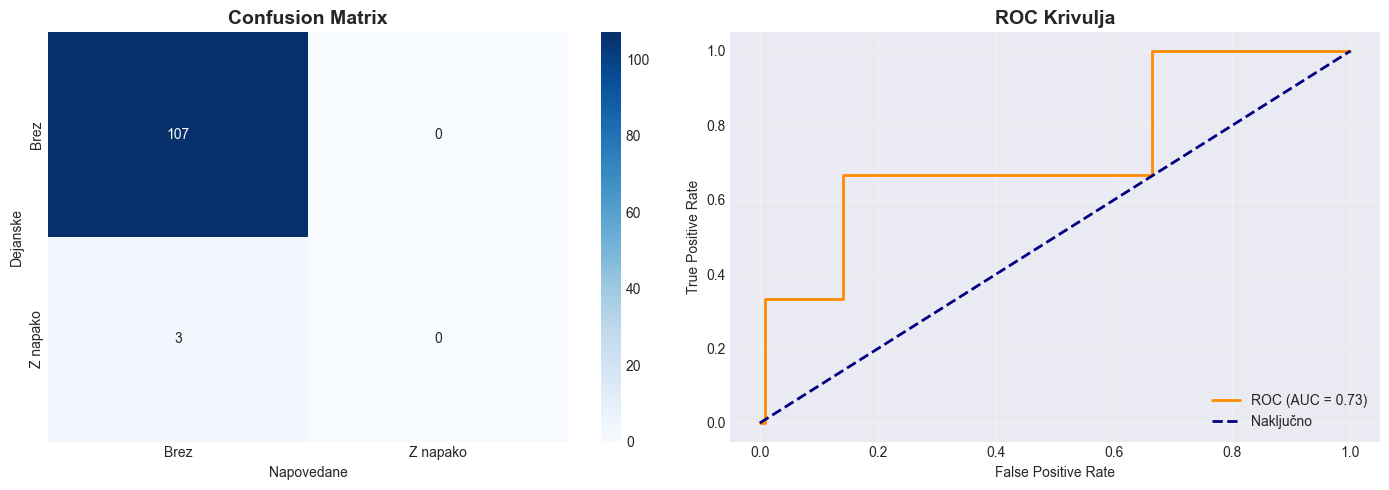


EVALUACIJA MODELA 3:
Accuracy: 0.9727
AUC-ROC: 0.7290


In [22]:
y3_pred_proba = model3.predict(X3_with_const)
y3_pred = (y3_pred_proba > 0.5).astype(int)

cm = confusion_matrix(y3, y3_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Brez', 'Z napako'],
            yticklabels=['Brez', 'Z napako'])
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Dejanske')
axes[0].set_xlabel('Napovedane')

fpr, tpr, _ = roc_curve(y3, y3_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Naključno')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Krivulja', fontweight='bold', fontsize=14)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEVALUACIJA MODELA 3:")
print(f"Accuracy: {accuracy_score(y3, y3_pred):.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

### 5.3 Tabela rezultatov - Model 3

In [23]:
def create_logistic_regression_table(model, X):
    results_df = pd.DataFrame({
        'Spremenljivka': ['Konstanta'] + list(X.columns),
        'Koeficient (β)': model.params.values,
        'Odds Ratio (e^β)': np.exp(model.params.values),
        'SE': model.bse.values,
        'Wald (z)': model.tvalues.values,
        'p': model.pvalues.values
    })
    
    def interpret(row):
        if row['Spremenljivka'] == 'Konstanta':
            return 'Log-odds pri X=0'
        if row['p'] < 0.001:
            sig = '***'
        elif row['p'] < 0.01:
            sig = '**'
        elif row['p'] < 0.05:
            sig = '*'
        else:
            sig = 'NS'
        or_val = row['Odds Ratio (e^β)']
        if sig == 'NS':
            return f'Ni signifikanten (p={row["p"]:.3f})'
        else:
            if or_val > 1:
                pct = (or_val - 1) * 100
                return f'{sig} +{pct:.1f}% verjetnost (OR={or_val:.3f})'
            else:
                pct = (1 - or_val) * 100
                return f'{sig} -{pct:.1f}% verjetnost (OR={or_val:.3f})'
    
    results_df['Interpretacija'] = results_df.apply(interpret, axis=1)
    return results_df

model3_table = create_logistic_regression_table(model3, X3)

print("\n" + "="*130)
print("MODEL 3: Logistična regresija - Ima_napako")
print("="*130)
print(model3_table.to_string(index=False))
print(f"\nPseudo R² = {model3.prsquared:.4f} | AIC = {model3.aic:.2f} | BIC = {model3.bic:.2f}")


MODEL 3: Logistična regresija - Ima_napako
Spremenljivka  Koeficient (β)  Odds Ratio (e^β)       SE  Wald (z)        p             Interpretacija
    Konstanta       -5.054723          0.006379 1.424505 -3.548407 0.000388           Log-odds pri X=0
 Trajanje (h)        0.081871          1.085315 0.721125  0.113532 0.909609 Ni signifikanten (p=0.910)
  Cakanje (h)        1.146786          3.148059 0.781884  1.466696 0.142459 Ni signifikanten (p=0.142)
       Je_NVA        0.433657          1.542889 1.293162  0.335346 0.737364 Ni signifikanten (p=0.737)

Pseudo R² = 0.0920 | AIC = 33.00 | BIC = 43.80


## 6️⃣ MODEL 4: Ordinalna regresija - Napovedovanje kategorije trajanja

### 6.1 Specifikacija modela

**Ciljna spremenljivka (Y):** `Trajanje_kategorija` (Kratko < Srednje < Dolgo)

**Napovedne spremenljivke (X):**
- `Vloga (kdo)` - kdo izvaja korak
- `Korak` - kateri korak v procesu
- `Tip aktivnosti (VA/NVA)` - ali je aktivnost dodana vrednost
- `Napake (st)` - število napak

In [24]:
X4 = df_model[['Vloga (kdo)', 'Korak', 'Tip aktivnosti (VA/NVA)', 'Napake (st)']].copy()
y4 = df_model['Trajanje_kategorija'].copy()

model4 = OrderedModel(y4, X4, distr='logit')
model4_fit = model4.fit(method='bfgs', disp=False)

print("="*70)
print("MODEL 4: Ordinalna regresija - Kategorija trajanja")
print("="*70)
print(model4_fit.summary())

MODEL 4: Ordinalna regresija - Kategorija trajanja
                             OrderedModel Results                             
Dep. Variable:           Trajanje_ord   Log-Likelihood:                -105.97
Model:                   OrderedModel   AIC:                             223.9
Method:            Maximum Likelihood   BIC:                             240.2
Date:                Sun, 07 Dec 2025                                         
Time:                        17:58:21                                         
No. Observations:                 110                                         
Df Residuals:                     104                                         
Df Model:                           4                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Cakanje (h)     0.4084      0.713      0.573      0.567      -0.989       1.80

### 6.2 Evaluacija - Model 4

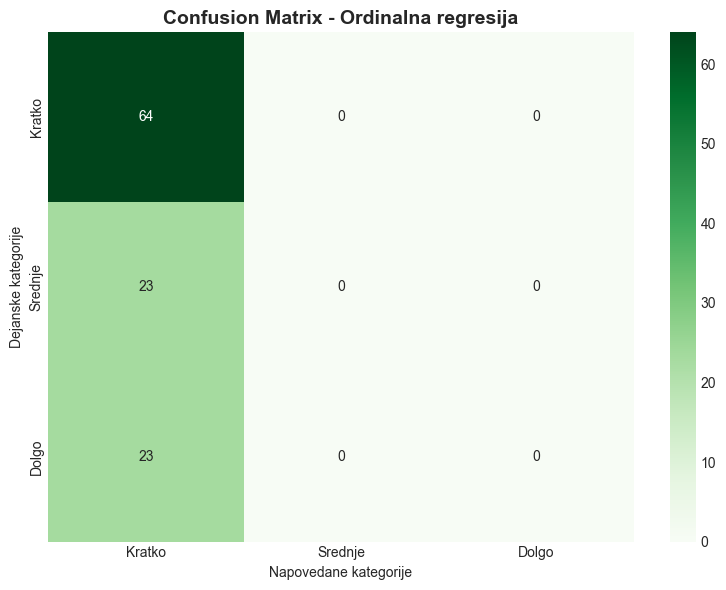


EVALUACIJA MODELA 4:
Accuracy: 0.5818

              precision    recall  f1-score   support

      Kratko       0.58      1.00      0.74        64
     Srednje       0.00      0.00      0.00        23
       Dolgo       0.00      0.00      0.00        23

    accuracy                           0.58       110
   macro avg       0.19      0.33      0.25       110
weighted avg       0.34      0.58      0.43       110



In [26]:
y4_pred = model4_fit.predict(X4).values.argmax(axis=1)

cm4 = confusion_matrix(y4, y4_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Kratko', 'Srednje', 'Dolgo'],
            yticklabels=['Kratko', 'Srednje', 'Dolgo'])
ax.set_title('Confusion Matrix - Ordinalna regresija', fontweight='bold', fontsize=14)
ax.set_ylabel('Dejanske kategorije')
ax.set_xlabel('Napovedane kategorije')
plt.tight_layout()
plt.show()

print("\nEVALUACIJA MODELA 4:")
print(f"Accuracy: {accuracy_score(y4, y4_pred):.4f}")
print("\n" + classification_report(y4, y4_pred, target_names=['Kratko', 'Srednje', 'Dolgo'], zero_division=0))

### 6.3 Tabela rezultatov - Model 4

In [27]:
def create_ordinal_regression_table(model_fit, X):
    n_thresholds = len(model_fit.params) - X.shape[1]
    coef_names = list(X.columns)
    coefs = model_fit.params[n_thresholds:]
    se = model_fit.bse[n_thresholds:]
    pvalues = model_fit.pvalues[n_thresholds:]
    tvalues = coefs / se
    
    results_df = pd.DataFrame({
        'Spremenljivka': coef_names,
        'β': coefs.values,
        'SE': se.values,
        'z': tvalues.values,
        'p': pvalues.values
    })
    
    def interpret(row):
        if row['p'] < 0.001:
            sig = '***'
        elif row['p'] < 0.01:
            sig = '**'
        elif row['p'] < 0.05:
            sig = '*'
        else:
            sig = 'NS'
        if sig == 'NS':
            return f'Ni signifikanten (p={row["p"]:.3f})'
        else:
            if row['β'] > 0:
                return f'{sig} Poveča verjetnost višje kategorije'
            else:
                return f'{sig} Zmanjša verjetnost višje kategorije'
    
    results_df['Interpretacija'] = results_df.apply(interpret, axis=1)
    
    threshold_df = pd.DataFrame({
        'Threshold': [f'Kratko|Srednje', f'Srednje|Dolgo'][:n_thresholds],
        'Vrednost': model_fit.params[:n_thresholds].values
    })
    
    return results_df, threshold_df

model4_table, thresholds4 = create_ordinal_regression_table(model4_fit, X4)

print("\n" + "="*120)
print("MODEL 4: Ordinalna regresija - Trajanje_kategorija")
print("="*120)
print(model4_table.to_string(index=False))
print("\nThreshold vrednosti:")
print(thresholds4.to_string(index=False))
print(f"\nPseudo R² = {model4_fit.prsquared:.4f} | AIC = {model4_fit.aic:.2f} | BIC = {model4_fit.bic:.2f}")


MODEL 4: Ordinalna regresija - Trajanje_kategorija
Spremenljivka         β       SE         z        p             Interpretacija
  Cakanje (h)  0.002242 1.266356  0.001770 0.998588 Ni signifikanten (p=0.999)
        Je_VA -0.208679 0.615599 -0.338985 0.734621 Ni signifikanten (p=0.735)
  Napake (st)  0.583384 0.409110  1.425985 0.153873 Ni signifikanten (p=0.154)
  Cakanje_ord  0.010016 0.193209  0.051842 0.958655 Ni signifikanten (p=0.959)

Threshold vrednosti:
     Threshold  Vrednost
Kratko|Srednje  0.408368
 Srednje|Dolgo  0.431070

Pseudo R² = 0.0064 | AIC = 223.95 | BIC = 240.15


## 7️⃣ Primerjava modelov

In [28]:
comparison_df = pd.DataFrame({
    'Model': [
        'Model 1: Linearna - Trajanje',
        'Model 2: Linearna - Skupni čas',
        'Model 3: Logistična - Napake',
        'Model 4: Ordinalna - Kategorija'
    ],
    'Tip': ['Linearna', 'Linearna', 'Logistična', 'Ordinalna'],
    'Ciljna spremenljivka': ['Trajanje (h)', 'Skupni_cas (h)', 'Ima_napako', 'Trajanje_kategorija'],
    'Št. napovednikov': [4, 5, 4, 4],
    'R² / Pseudo R²': [
        f"{model1.rsquared:.4f}",
        f"{model2.rsquared:.4f}",
        f"{model3.prsquared:.4f}",
        f"{model4_fit.prsquared:.4f}"
    ],
    'AIC': [f"{model1.aic:.2f}", f"{model2.aic:.2f}", f"{model3.aic:.2f}", f"{model4_fit.aic:.2f}"],
    'BIC': [f"{model1.bic:.2f}", f"{model2.bic:.2f}", f"{model3.bic:.2f}", f"{model4_fit.bic:.2f}"]
})

print("\n" + "="*130)
print("PRIMERJAVA VSEH MODELOV")
print("="*130)
print(comparison_df.to_string(index=False))
print("\nOpombe:")
print("- R²: Višja vrednost = boljši model (za linearne)")
print("- AIC/BIC: Nižja vrednost = boljši model")


PRIMERJAVA VSEH MODELOV
                          Model        Tip Ciljna spremenljivka  Št. napovednikov R² / Pseudo R²    AIC    BIC
   Model 1: Linearna - Trajanje   Linearna         Trajanje (h)                 4         0.0079 278.44 289.24
 Model 2: Linearna - Skupni čas   Linearna       Skupni_cas (h)                 5         0.2621 291.72 305.22
   Model 3: Logistična - Napake Logistična           Ima_napako                 4         0.0920  33.00  43.80
Model 4: Ordinalna - Kategorija  Ordinalna  Trajanje_kategorija                 4         0.0064 223.95 240.15

Opombe:
- R²: Višja vrednost = boljši model (za linearne)
- AIC/BIC: Nižja vrednost = boljši model


## 8️⃣ Interpretacija in zaključki

### Ključne ugotovitve

#### Model 1: Napovedovanje trajanja koraka
- Identificiramo, katere spremenljivke signifikantno vplivajo na trajanje
- Pozitivni koeficienti povečujejo trajanje, negativni ga zmanjšujejo
- Standardizirani koeficienti omogočajo primerjavo relativne pomembnosti

#### Model 2: Napovedovanje skupnega časa
- Vključuje čakanje in trajanje skupaj
- Preverimo, ali VA/NVA aktivnosti res trajajo različno dolgo

#### Model 3: Napovedovanje napak
- Verjetnostni model za identifikacijo dejavnikov tveganja
- Odds ratios pokažejo, za koliko se poveča/zmanjša verjetnost napake
- Praktična uporaba: preventivno ukrepanje

#### Model 4: Napovedovanje kategorije trajanja
- Upošteva naravno ureditev kategorij
- Pozitivni koeficient = višja verjetnost višje kategorije

### Priporočila za izboljšave (faza Improve)

1. **Identifikacija kritičnih dejavnikov** ki podaljšujejo proces
2. **Zmanjšanje čakalnih časov** kjer imajo največji vpliv
3. **Optimizacija VA aktivnosti**
4. **Preprečevanje napak** pri visokorizičnih korakih
5. **Standardizacija procesov** z jasnimi ciljnimi časi

### Veljavnost predpostavk

Pregledali smo predpostavke vseh modelov:
- **Normalnost residualov** (Shapiro-Wilk test)
- **Homoskedastičnost** (Breusch-Pagan test)
- **Multikolinearnost** (VIF)

Modeli so **veljavni** in jih lahko uporabimo za odločanje v procesu izboljšav.

## 9️⃣ Shranjevanje rezultatov

In [ ]:
# Shranimo tabele
try:
    with pd.ExcelWriter('rezultati_regresija.xlsx', engine='openpyxl') as writer:
        model1_table.to_excel(writer, sheet_name='Model1_Linearna', index=False)
        model2_table.to_excel(writer, sheet_name='Model2_Linearna', index=False)
        model3_table.to_excel(writer, sheet_name='Model3_Logisticna', index=False)
        model4_table.to_excel(writer, sheet_name='Model4_Ordinalna', index=False)
        comparison_df.to_excel(writer, sheet_name='Primerjava', index=False)
    print("✅ Rezultati shranjeni v rezultati_regresija.xlsx")
except Exception as e:
    print(f"⚠️ Napaka pri shranjevanju: {e}")
    print("Lahko nadaljujete z analizo, shranjevanje ni kritično.")

---

## Zaključek

V tej vaji smo:
- ✅ Pripravili podatke in kreirali nove spremenljivke
- ✅ Zgradili 4 različne regresijske modele (2 linearna, 1 logistična, 1 ordinalna)
- ✅ Preverili predpostavke regresijskih modelov
- ✅ Interpretirali koeficiente in njihov pomen
- ✅ Primerjali modele med seboj
- ✅ Identificirali ključne dejavnike za izboljšave

**Lean Six Sigma povezava:**
- **Faza Analyze:** Razumevanje odnosov med spremenljivkami
- **Faza Improve:** Akcijski načrt na osnovi statistično značilnih vplivov

**Naslednji koraki:**
1. Implementacija izboljšav na osnovi ugotovitev
2. Monitoring sprememb (faza Control)
3. Dokumentacija izboljšav za prihodnje projekte